# DQN RL Training
Trains the DQN agent on `NetworkEnv` using GNN-encoded states from the pretrained encoder.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from envs.network_env import NetworkEnv
from agents.dqn_agent import DQNAgent
from models.encoder import GraphEncoder
from utils.metrics import summarize_episode

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
with open('../configs/config.yaml') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Load Pretrained GNN Encoder

In [3]:
encoder = GraphEncoder(in_channels=3, hidden_channels=64, out_channels=32).to(device)
gnn_path = '../results/gnn_pretrained.pt'

if os.path.exists(gnn_path):
    encoder.gnn.load_state_dict(torch.load(gnn_path, map_location=device))
    print(f'Loaded pretrained GNN from {gnn_path}')
else:
    print('No pretrained GNN found — using random encoder weights. Run train_gnn.ipynb first.')

encoder.eval()

Loaded pretrained GNN from ../results/gnn_pretrained.pt


GraphEncoder(
  (gnn): GNNModel(
    (conv1): GCNConv(3, 64)
    (conv2): GATConv(64, 64, heads=4)
    (conv3): GCNConv(64, 32)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pool_fc): Linear(in_features=32, out_features=32, bias=True)
)

## Setup Environment & Agent

In [4]:
env = NetworkEnv(config)
env.reset()
state_dim = env.get_gnn_state(encoder, device).shape[0]
action_dim = env.action_space.n

print(f'GNN state dim: {state_dim} | Action space: {action_dim}')

agent = DQNAgent(state_dim, action_dim, config)

GNN state dim: 1342 | Action space: 300


## Training Loop

In [5]:
episodes = config['training']['episodes']
episode_rewards = []

for ep in range(1, episodes + 1):
    env.reset()
    state = env.get_gnn_state(encoder, device)
    ep_rewards = []
    done = False

    while not done:
        action = agent.select_action(state)
        _, reward, done, _ = env.step(action)
        next_state = env.get_gnn_state(encoder, device)
        agent.store(state, action, reward, next_state, float(done))
        agent.train_step()
        state = next_state
        ep_rewards.append(reward)

    if ep % 10 == 0:
        agent.update_target()

    stats = summarize_episode(ep_rewards)
    episode_rewards.append(stats['total_reward'])

    if ep % 50 == 0:
        os.makedirs('../results', exist_ok=True)
        agent.save(f'../results/dqn_ep{ep}.pt')
        print(f'Episode {ep}/{episodes} | Total Reward: {stats["total_reward"]:.3f} | ε: {agent.epsilon:.3f}')

print('Training complete.')

Episode 50/500 | Total Reward: 62.290 | ε: 0.050
Episode 100/500 | Total Reward: 61.530 | ε: 0.050
Episode 150/500 | Total Reward: 71.567 | ε: 0.050
Episode 200/500 | Total Reward: 33.444 | ε: 0.050
Episode 250/500 | Total Reward: 39.705 | ε: 0.050
Episode 300/500 | Total Reward: 33.004 | ε: 0.050
Episode 350/500 | Total Reward: 51.390 | ε: 0.050
Episode 400/500 | Total Reward: 46.276 | ε: 0.050
Episode 450/500 | Total Reward: 51.849 | ε: 0.050
Episode 500/500 | Total Reward: 53.202 | ε: 0.050
Training complete.


## Reward Curve

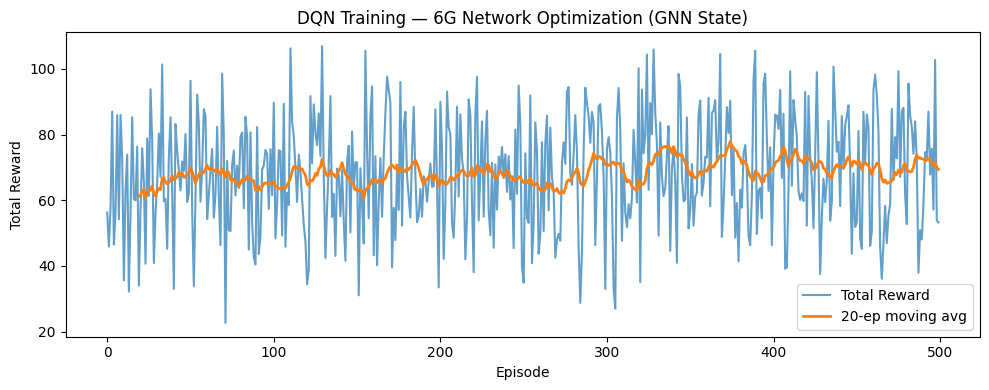

Plot saved to results/plots/dqn_rewards.png


In [7]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.7, label='Total Reward')

# Smoothed curve
window = 20
if len(episode_rewards) >= window:
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window - 1, len(episode_rewards)), smoothed, linewidth=2, label=f'{window}-ep moving avg')

plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN Training — 6G Network Optimization (GNN State)')
plt.legend()
plt.tight_layout()
os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/dqn_rewards.png')
plt.show()
print('Plot saved to results/plots/dqn_rewards.png')

## Evaluate Trained Agent (1 Episode)

In [8]:
agent.epsilon = 0.0  # greedy
env.reset()
state = env.get_gnn_state(encoder, device)
eval_rewards, done = [], False

while not done:
    action = agent.select_action(state)
    _, reward, done, _ = env.step(action)
    state = env.get_gnn_state(encoder, device)
    eval_rewards.append(reward)

stats = summarize_episode(eval_rewards)
print('Eval episode stats:')
for k, v in stats.items():
    print(f'  {k}: {v:.4f}')

Eval episode stats:
  total_reward: 103.8797
  mean_reward: 0.5194
  min_reward: 0.5142
  max_reward: 0.5282


## Network Topology Visualisation

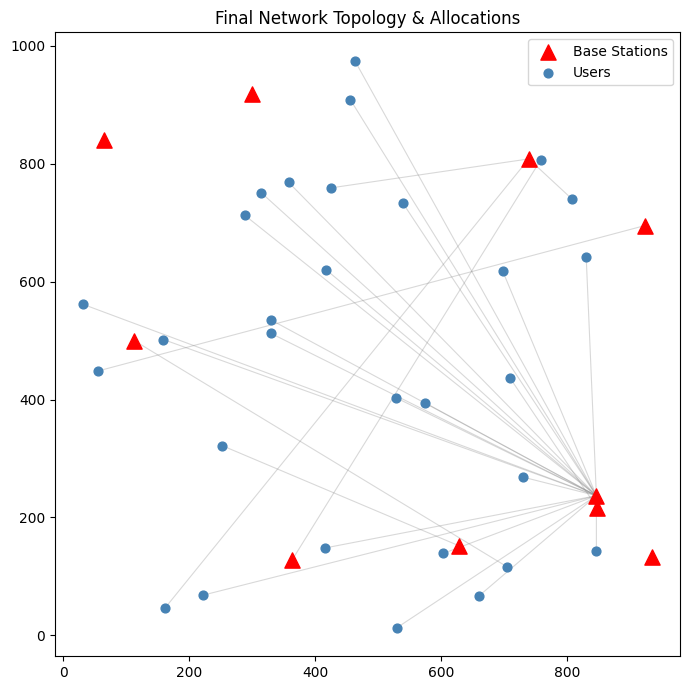

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
bs = env.bs_positions
users = env.user_positions

ax.scatter(bs[:, 0], bs[:, 1], c='red', marker='^', s=120, label='Base Stations', zorder=3)
ax.scatter(users[:, 0], users[:, 1], c='steelblue', marker='o', s=40, label='Users', zorder=3)

for u in range(env.num_users):
    b = env.allocations[u]
    ax.plot([users[u, 0], bs[b, 0]], [users[u, 1], bs[b, 1]], 'gray', alpha=0.3, linewidth=0.8)

ax.set_title('Final Network Topology & Allocations')
ax.legend()
plt.tight_layout()
plt.show()